# 02 — Fleet Simulation (7-day, uncontrolled charging)

1. Load data & build trip chains
2. Run fleet simulation (500 EVs first, then full fleet)
3. Aggregate load curves (weekday vs weekend)
4. Fleet-level statistics & SOC heatmap
5. Validation checks
6. Export results

In [ ]:
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import mobility as em
from mobility.core import simulate_fleet, STEPS_PER_DAY, STEP_HOURS

%matplotlib inline
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['figure.dpi'] = 100

OUTPUT_DIR = Path('..') / 'output'
OUTPUT_DIR.mkdir(exist_ok=True)
NUM_DAYS = 7
print('Ready.')


## 1. Load Data & Build Trip Chains

In [2]:
trips, fleet, stations = em.load_all()
pools = em.build_trip_chain_pools(trips)
print(f'Fleet size: {len(fleet):,} EVs')
print(f'Weekday chains: {len(pools["weekday"]):,}')
print(f'Weekend chains: {len(pools["weekend"]):,}')

Fleet size: 1,582,682 EVs
Weekday chains: 109,756
Weekend chains: 41,676


## 2. Pilot Run — 500 EVs

In [3]:
PILOT_N = 500
pilot_fleet = fleet.iloc[:PILOT_N].copy()

t0 = time.time()
pilot_schedules = em.assign_chains_to_fleet(pilot_fleet, pools, num_days=NUM_DAYS, seed=42)
em.match_stations_for_fleet(pilot_schedules, pilot_fleet, stations)
print(f'Trip chains assigned & stations matched in {time.time()-t0:.1f}s')

t0 = time.time()
pilot_results = simulate_fleet(pilot_schedules, pilot_fleet, progress_interval=100)
elapsed = time.time() - t0
print(f'\nSimulation done in {elapsed:.1f}s ({elapsed/PILOT_N*1000:.1f}ms per EV)')
print(f'Estimated full fleet ({len(fleet):,}): {elapsed/PILOT_N*len(fleet)/60:.0f} min')

Trip chains assigned & stations matched in 0.1s
  Simulated 100/500 EVs
  Simulated 200/500 EVs
  Simulated 300/500 EVs
  Simulated 400/500 EVs
  Simulated 500/500 EVs

Simulation done in 0.6s (1.2ms per EV)
Estimated full fleet (1,582,682): 31 min


### Quick sanity check on pilot

  num_evs: 500
  num_days: 7
  peak_fleet_load_kw: 277.45232903987016
  mean_daily_fleet_charge_kwh: 2589.211231419841
  fleet_min_soc: 0.0
  fleet_mean_soc: 0.9782560421985264


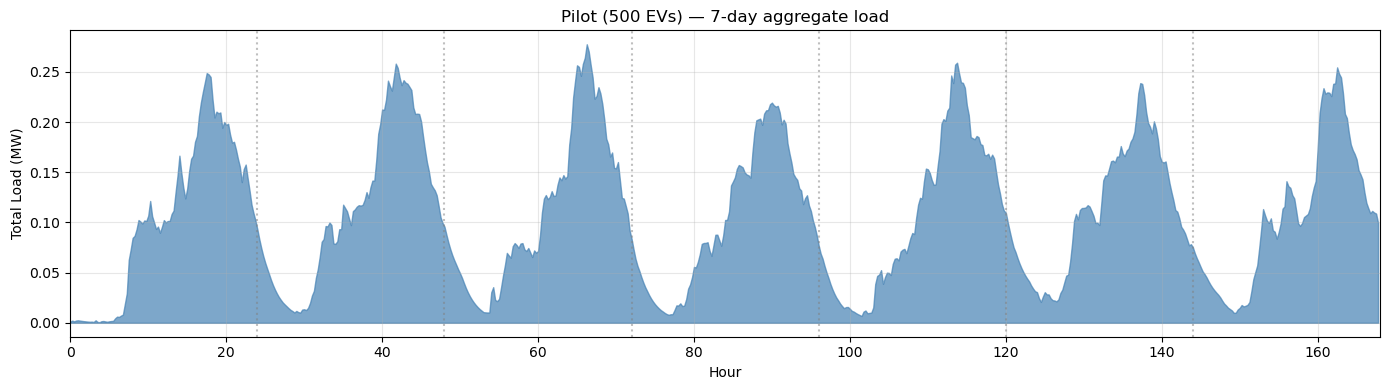

Pilot looks reasonable — proceed to full fleet.


In [4]:
pilot_summary = em.fleet_summary(pilot_results, pilot_fleet, NUM_DAYS)
for k, v in pilot_summary.items():
    print(f'  {k}: {v}')

# Quick load curve
pilot_load = em.aggregate_load_profile(pilot_results)
hours_7d = np.arange(len(pilot_load)) * STEP_HOURS
plt.figure(figsize=(14, 4))
plt.fill_between(hours_7d, pilot_load / 1000, alpha=0.7, color='steelblue')
plt.xlabel('Hour'); plt.ylabel('Total Load (MW)')
plt.title(f'Pilot ({PILOT_N} EVs) — 7-day aggregate load')
plt.xlim(0, NUM_DAYS * 24)
for d in range(1, NUM_DAYS):
    plt.axvline(d * 24, color='grey', ls=':', alpha=0.5)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
print('Pilot looks reasonable — proceed to full fleet.' if pilot_load.max() > 0 else 'WARNING: zero load!')

## 3. Full Fleet Simulation

In [ ]:
t0 = time.time()
all_schedules = em.assign_chains_to_fleet(
    fleet, pools, num_days=NUM_DAYS, seed=42, progress_interval=200_000
)
print(f'Trip chain assignment: {time.time()-t0:.1f}s')

t0 = time.time()
em.match_stations_for_fleet(all_schedules, fleet, stations)
print(f'Station matching: {time.time()-t0:.1f}s')

t0 = time.time()
results = simulate_fleet(all_schedules, fleet, progress_interval=200_000)
print(f'\nFull fleet simulation: {time.time()-t0:.1f}s')

## 4. Aggregate Load Curves — Weekday vs Weekend

In [ ]:
total_load = em.aggregate_load_profile(results)
daily_load = total_load.reshape(NUM_DAYS, STEPS_PER_DAY)  # shape (7, 96)
hours_24 = np.arange(STEPS_PER_DAY) * STEP_HOURS

# Days 0-4 = weekday (Mon-Fri), 5-6 = weekend (Sat-Sun)
weekday_load = daily_load[:5].mean(axis=0) / 1000   # kW → MW
weekend_load = daily_load[5:].mean(axis=0) / 1000

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# --- Left: weekday vs weekend overlay ---
ax = axes[0]
ax.fill_between(hours_24, weekday_load, alpha=0.4, color='steelblue', label='Weekday avg')
ax.fill_between(hours_24, weekend_load, alpha=0.4, color='coral', label='Weekend avg')
ax.plot(hours_24, weekday_load, color='steelblue', lw=1.5)
ax.plot(hours_24, weekend_load, color='coral', lw=1.5)

# Annotate peaks
wd_peak_idx = np.argmax(weekday_load)
we_peak_idx = np.argmax(weekend_load)
ax.annotate(f'Peak {weekday_load[wd_peak_idx]:.1f} MW\n@ {hours_24[wd_peak_idx]:.1f}h',
            xy=(hours_24[wd_peak_idx], weekday_load[wd_peak_idx]),
            xytext=(hours_24[wd_peak_idx]+2, weekday_load[wd_peak_idx]*1.05),
            arrowprops=dict(arrowstyle='->', color='steelblue'),
            color='steelblue', fontsize=9)
ax.annotate(f'Peak {weekend_load[we_peak_idx]:.1f} MW\n@ {hours_24[we_peak_idx]:.1f}h',
            xy=(hours_24[we_peak_idx], weekend_load[we_peak_idx]),
            xytext=(hours_24[we_peak_idx]-6, weekend_load[we_peak_idx]*1.05),
            arrowprops=dict(arrowstyle='->', color='coral'),
            color='coral', fontsize=9)

ax.set_xlabel('Hour of Day')
ax.set_ylabel('Total Charging Load (MW)')
ax.set_title('Weekday vs Weekend — Average Daily Load')
ax.set_xlim(0, 24)
ax.legend()
ax.grid(True, alpha=0.3)

# --- Right: all 7 days stacked ---
ax = axes[1]
day_labels = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
colors = plt.cm.tab10(np.linspace(0, 1, 7))
for d in range(NUM_DAYS):
    ax.plot(hours_24, daily_load[d] / 1000, color=colors[d],
            lw=1.5, alpha=0.8, label=day_labels[d])
ax.set_xlabel('Hour of Day')
ax.set_ylabel('Total Charging Load (MW)')
ax.set_title('7-Day Load Profile Overlay')
ax.set_xlim(0, 24)
ax.legend(ncol=4, fontsize=8)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f'Weekday peak: {weekday_load.max():.2f} MW @ {hours_24[wd_peak_idx]:.2f}h')
print(f'Weekend peak: {weekend_load.max():.2f} MW @ {hours_24[we_peak_idx]:.2f}h')

## 5. Fleet-level Statistics

In [ ]:
stats = em.compute_statistics(results, fleet, NUM_DAYS)

fig, axes = plt.subplots(1, 3, figsize=(17, 4.5))

# (a) Mean daily SOC distribution
ax = axes[0]
ax.hist(stats['mean_soc'] * 100, bins=50, color='steelblue', edgecolor='white')
ax.axvline(stats['mean_soc'].mean() * 100, color='red', ls='--',
           label=f'Fleet mean = {stats["mean_soc"].mean()*100:.1f}%')
ax.set_xlabel('Mean SOC (%)')
ax.set_ylabel('Number of EVs')
ax.set_title('(a) Mean SOC Distribution')
ax.legend(fontsize=8)

# (b) Mean daily charge distribution
ax = axes[1]
ax.hist(stats['mean_daily_charge_kwh'], bins=50, color='coral', edgecolor='white')
ax.axvline(stats['mean_daily_charge_kwh'].mean(), color='red', ls='--',
           label=f'Fleet mean = {stats["mean_daily_charge_kwh"].mean():.1f} kWh/day')
ax.set_xlabel('Mean Daily Charge (kWh)')
ax.set_ylabel('Number of EVs')
ax.set_title('(b) Daily Charging Amount')
ax.legend(fontsize=8)

# (c) Min SOC distribution (worst case per EV)
ax = axes[2]
ax.hist(stats['min_soc'] * 100, bins=50, color='seagreen', edgecolor='white')
n_low = (stats['min_soc'] < 0.2).sum()
ax.axvline(20, color='red', ls='--', label=f'20% threshold ({n_low} EVs below)')
ax.set_xlabel('Minimum SOC (%)')
ax.set_ylabel('Number of EVs')
ax.set_title('(c) Minimum SOC (worst moment in 7 days)')
ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

print(stats.describe().round(2))

### SOC Heatmap (Day 0 — Monday)

In [ ]:
# Build SOC matrix for day 0 — sample up to 500 EVs for readability
ev_ids = sorted(results.keys())
sample_ids = ev_ids[:500]
soc_day0 = np.array([results[eid]['soc'][:STEPS_PER_DAY] for eid in sample_ids])

# Sort EVs by their mean SOC for visual clarity
sort_idx = np.argsort(soc_day0.mean(axis=1))
soc_day0 = soc_day0[sort_idx]

fig, ax = plt.subplots(figsize=(14, 6))
im = ax.imshow(soc_day0 * 100, aspect='auto', cmap='RdYlGn',
               vmin=0, vmax=100,
               extent=[0, 24, len(sample_ids), 0])
ax.set_xlabel('Hour of Day')
ax.set_ylabel(f'EV index (n={len(sample_ids)}, sorted by mean SOC)')
ax.set_title('SOC Heatmap — Day 0 (Monday)')
cbar = plt.colorbar(im, ax=ax, label='SOC (%)')
plt.tight_layout()
plt.show()

## 6. Validation Checks

In [ ]:
print('=== Validation Checks ===')
print()

# --- (a) Daily mileage ---
# Compute total distance per EV per day from schedules
daily_km = []
for ev_id, day_scheds in all_schedules.items():
    for ds in day_scheds:
        day_dist = sum(t.distance_km for t in ds.trips)
        daily_km.append(day_dist)
daily_km = np.array(daily_km)
mean_daily_km = daily_km.mean()
print(f'(a) Mean daily mileage: {mean_daily_km:.1f} km')
print(f'    Median: {np.median(daily_km):.1f} km, Std: {daily_km.std():.1f} km')
if 30 <= mean_daily_km <= 50:
    print('    OK — within expected UK EV range (30-50 km/day)')
else:
    print(f'    WARNING — outside 30-50 km/day range')
print()

# --- (b) Peak charging time ---
wd_peak_hour = hours_24[np.argmax(weekday_load)]
we_peak_hour = hours_24[np.argmax(weekend_load)]
print(f'(b) Weekday peak charging: {wd_peak_hour:.1f}h ({weekday_load.max():.2f} MW)')
print(f'    Weekend peak charging: {we_peak_hour:.1f}h ({weekend_load.max():.2f} MW)')
if 16 <= wd_peak_hour <= 22:
    print('    OK — weekday peak in expected evening window (16-22h)')
else:
    print(f'    NOTE — weekday peak outside typical 16-22h window')
print()

# --- (c) Energy balance: daily charge vs daily consumption ---
mean_daily_charge = stats['mean_daily_charge_kwh'].mean()
# Mean consumption per EV per day
consumption_map = fleet.set_index('EV_ID')['battery_capacity_kwh'].to_dict()
daily_energy = []
for ev_id, day_scheds in all_schedules.items():
    for ds in day_scheds:
        day_e = sum(t.energy_consumed_kwh for t in ds.trips)
        daily_energy.append(day_e)
daily_energy = np.array(daily_energy)
mean_daily_consumed = daily_energy.mean()

print(f'(c) Mean daily charge per EV:       {mean_daily_charge:.2f} kWh')
print(f'    Mean daily consumption per EV:   {mean_daily_consumed:.2f} kWh')
ratio = mean_daily_charge / mean_daily_consumed if mean_daily_consumed > 0 else float('inf')
print(f'    Charge / consumption ratio:      {ratio:.2f}')
if 0.9 <= ratio <= 1.1:
    print('    OK — charge closely matches consumption (ratio near 1.0)')
else:
    print(f'    NOTE — ratio deviates from 1.0 (expected if SOC drifts over 7 days)')
print()

# --- Fleet summary ---
summary = em.fleet_summary(results, fleet, NUM_DAYS)
print('=== Fleet Summary ===')
for k, v in summary.items():
    if isinstance(v, float):
        print(f'  {k}: {v:.2f}')
    else:
        print(f'  {k}: {v}')

## 7. Export Results

In [ ]:
# (a) Aggregate load curve — CSV
load_df = pd.DataFrame({
    'hour': np.arange(len(total_load)) * STEP_HOURS,
    'day': np.repeat(range(NUM_DAYS), STEPS_PER_DAY),
    'day_label': np.repeat(['Mon','Tue','Wed','Thu','Fri','Sat','Sun'], STEPS_PER_DAY),
    'total_kw': total_load,
})
load_df.to_csv(OUTPUT_DIR / 'aggregate_load.csv', index=False)
print(f'Saved: {OUTPUT_DIR / "aggregate_load.csv"}')

# (b) Summary stats — CSV
stats.to_csv(OUTPUT_DIR / 'summary_stats.csv', index=False)
print(f'Saved: {OUTPUT_DIR / "summary_stats.csv"}')

# (c) Full export (numpy + CSVs)
em.export_results(results, fleet, NUM_DAYS, OUTPUT_DIR)
print(f'Saved: fleet_load_profile.csv, ev_statistics.csv, fleet_load.npy, fleet_soc.npy')

# List output files
print(f'\nOutput directory: {OUTPUT_DIR.resolve()}')
for f in sorted(OUTPUT_DIR.iterdir()):
    size_mb = f.stat().st_size / 1024 / 1024
    print(f'  {f.name:40s} {size_mb:8.2f} MB')